# Car Price Analysis

**Author:** Jelena Kosenko  
**Tools:** Python, Pandas, Scikit-learn, Matplotlib  
**Dataset:** Synthetic dataset — 2,250 rows, 10 features  

**Goal:** Build a linear regression model to predict car prices and identify key pricing factors.

## 1. Setup & Data Loading

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset from Google Drive
df = pd.read_csv('/content/drive/MyDrive/Data/car_price_prediction_with_missing.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nSample data:')
df.head()

Shape: (2500, 10)

Columns: ['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage', 'Condition', 'Price', 'Model']

Sample data:


,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1.0,Tesla,2016.0,2.3,Petrol,Manual,114832.0,New,26613.92,Model X
1,2.0,BMW,2018.0,4.4,Electric,Manual,143190.0,Used,14679.61,5 Series
2,3.0,Audi,2013.0,4.5,Electric,Manual,181601.0,New,44402.61,A4
3,4.0,Tesla,2011.0,4.1,Diesel,Automatic,68682.0,New,86374.33,Model Y
4,5.0,Ford,2009.0,2.6,Diesel,Manual,223009.0,Like New,73577.10,Mustang


## 2. Data Cleaning

In [3]:
# Check missing values
df.isnull().sum()

,0
Car ID,250
Brand,250
Year,250
Engine Size,250
Fuel Type,250
Transmission,250
Mileage,250
Condition,250
Price,250
Model,250


In [4]:
# Drop rows with missing values
df = df.dropna()
print('Shape after cleaning:', df.shape)

# Confirm no missing values remain
df.isnull().sum()

Shape after cleaning: (2250, 10)


,0
Car ID,0
Brand,0
Year,0
Engine Size,0
Fuel Type,0
Transmission,0
Mileage,0
Condition,0
Price,0
Model,0


## 3. Exploratory Data Analysis (EDA)

In [5]:
# Overview of numeric features
df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000
mean,1251.243556,2011.577778,3.485467,150236.178222,52506.874391
std,725.637358,6.980468,1.427690,88150.746556,27232.417079
min,1.000000,2000.000000,1.000000,15.000000,5011.270000
25%,627.250000,2005.000000,2.300000,71178.500000,28985.052500
50%,1249.500000,2012.000000,3.450000,149762.000000,53485.240000
75%,1875.250000,2018.000000,4.700000,226299.000000,75560.340000
max,2500.000000,2023.000000,6.000000,299967.000000,99982.590000


In [6]:
# Distribution of categorical features
print('--- Brand ---')
print(df['Brand'].value_counts())

print('\n--- Fuel Type ---')
print(df['Fuel Type'].value_counts())

print('\n--- Condition ---')
print(df['Condition'].value_counts())

print('\n--- Transmission ---')
print(df['Transmission'].value_counts())

print('\n--- Unique Models ---')
print(df['Model'].nunique())

--- Brand ---
Brand
Toyota      346
Mercedes    331
BMW         326
Audi        323
Tesla       314
Ford        307
Honda       303
Name: count, dtype: int64

--- Fuel Type ---
Fuel Type
Diesel      587
Petrol      561
Electric    554
Hybrid      548
Name: count, dtype: int64

--- Condition ---
Condition
Used        769
Like New    746
New         735
Name: count, dtype: int64

--- Transmission ---
Transmission
Manual       1184
Automatic    1066
Name: count, dtype: int64

--- Unique Models ---
28


In [7]:
# Average price by key categorical features
print('Avg Price by Brand:')
print(df.groupby('Brand')['Price'].mean().sort_values(ascending=False).round(0))

print('\nAvg Price by Fuel Type:')
print(df.groupby('Fuel Type')['Price'].mean().sort_values(ascending=False).round(0))

print('\nAvg Price by Condition:')
print(df.groupby('Condition')['Price'].mean().sort_values(ascending=False).round(0))

Avg Price by Brand:
Brand
BMW         54153.0
Mercedes    53080.0
Tesla       52678.0
Audi        52255.0
Toyota      51942.0
Honda       51812.0
Ford        51552.0
Name: Price, dtype: float64

Avg Price by Fuel Type:
Fuel Type
Diesel      54884.0
Hybrid      52602.0
Petrol      51626.0
Electric    50786.0
Name: Price, dtype: float64

Avg Price by Condition:
Condition
Like New    53003.0
Used        52608.0
New         51898.0
Name: Price, dtype: float64


In [8]:
# Numeric feature distributions
print('Mileage stats:')
print(df['Mileage'].describe())

print('\nYear stats:')
print(df['Year'].describe())

print('\nEngine Size stats:')
print(df['Engine Size'].describe())

Mileage stats:
count      2250.000000
mean     150236.178222
std       88150.746556
min          15.000000
25%       71178.500000
50%      149762.000000
75%      226299.000000
max      299967.000000
Name: Mileage, dtype: float64

Year stats:
count    2250.000000
mean     2011.577778
std         6.980468
min      2000.000000
25%      2005.000000
50%      2012.000000
75%      2018.000000
max      2023.000000
Name: Year, dtype: float64

Engine Size stats:
count    2250.000000
mean        3.485467
std         1.427690
min         1.000000
25%         2.300000
50%         3.450000
75%         4.700000
max         6.000000
Name: Engine Size, dtype: float64


In [9]:
# Correlation with target variable (Price)
df.corr(numeric_only=True)['Price'].sort_values(ascending=False)

,Price
Price,1.000000
Car ID,0.006645
Mileage,-0.009638
Engine Size,-0.013270
Year,-0.035127


## 4. Feature Engineering

In [10]:
# Create 'Age' feature from Year (more intuitive than raw year)
df['Age'] = 2026 - df['Year']
print('Sample Age vs Year:')
print(df[['Year', 'Age']].head())

Sample Age vs Year:
     Year   Age
0  2016.0  10.0
1  2018.0   8.0
2  2013.0  13.0
3  2011.0  15.0
4  2009.0  17.0


In [11]:
# One-hot encode categorical variables
df_model = pd.get_dummies(df, columns=['Brand', 'Fuel Type', 'Transmission', 'Condition'])
print('Shape after encoding:', df_model.shape)

Shape after encoding: (2250, 23)


## 5. Linear Regression Model

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# Define features and target
X = df_model.drop(columns=['Price', 'Car ID', 'Year', 'Model'])
y = df_model['Price']

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (1800, 19)
Test size: (450, 19)


In [13]:
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [14]:
# Evaluate model performance
y_pred = model.predict(X_test)

r2 = round(r2_score(y_test, y_pred), 3)
mae = round(mean_absolute_error(y_test, y_pred), 0)

print(f'R-squared: {r2}')
print(f'Mean Absolute Error: ${mae:,.0f}')

R-squared: 0.002
Mean Absolute Error: $23,396


## 6. Visualization

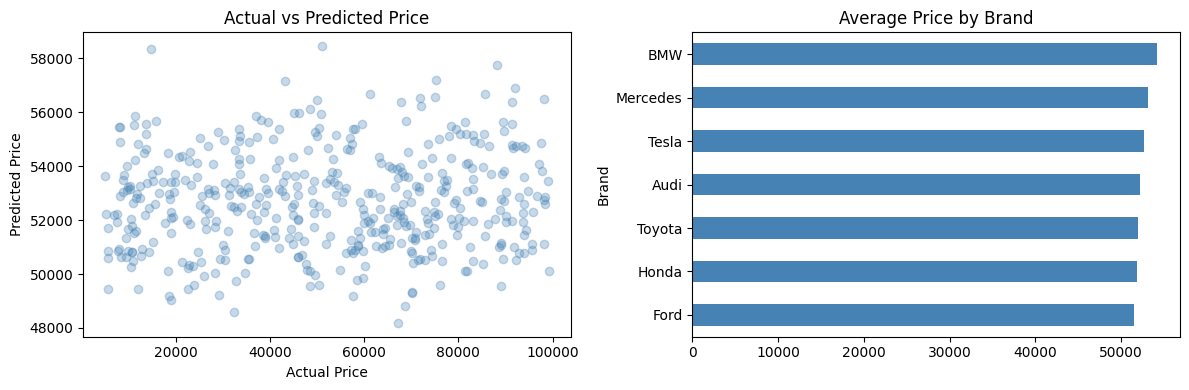

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Actual vs Predicted — visualizes model quality
axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue')
axes[0].set_title('Actual vs Predicted Price')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

# Average price per brand
df.groupby('Brand')['Price'].mean().sort_values().plot(
    kind='barh', ax=axes[1], title='Average Price by Brand', color='steelblue')

plt.tight_layout()
plt.show()

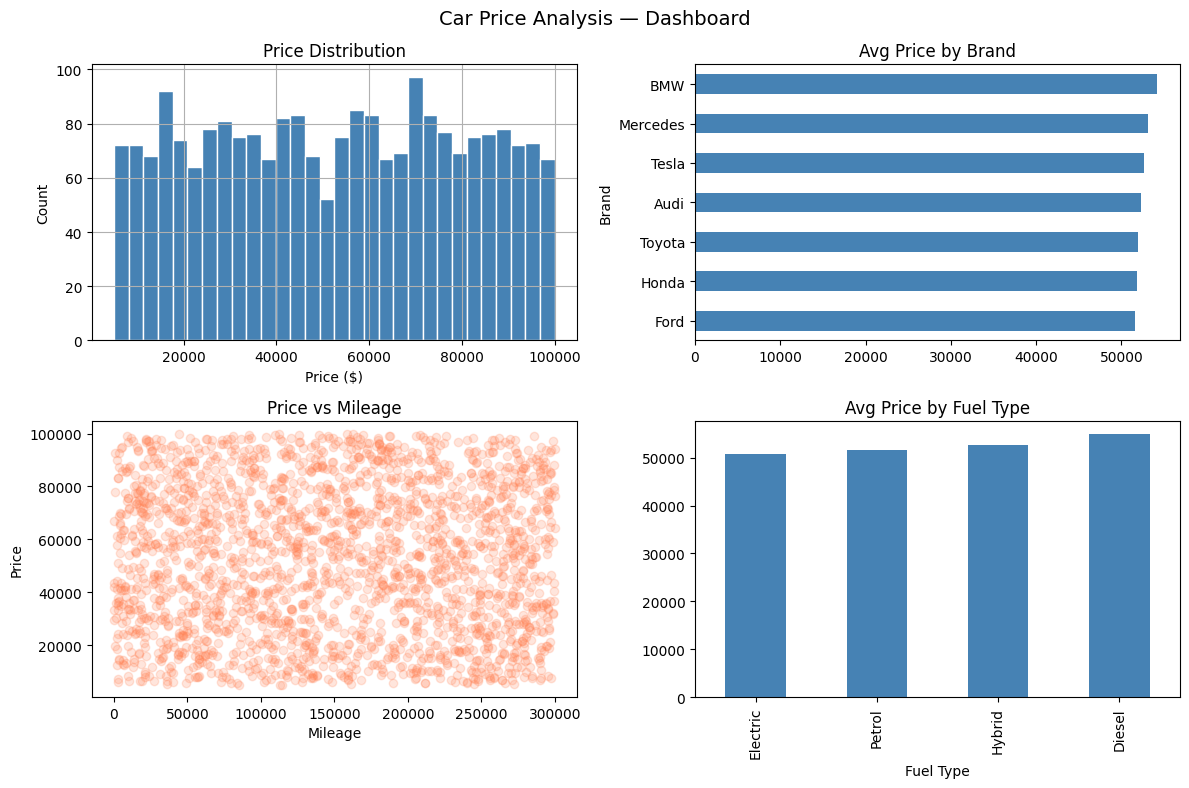

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Car Price Analysis — Dashboard', fontsize=14)

# 1. Price distribution
df['Price'].hist(bins=30, ax=axes[0, 0], color='steelblue', edgecolor='white')
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('Count')

# 2. Average price by brand
df.groupby('Brand')['Price'].mean().sort_values().plot(
    kind='barh', ax=axes[0, 1], title='Avg Price by Brand', color='steelblue')

# 3. Price vs Mileage — shows lack of correlation
axes[1, 0].scatter(df['Mileage'], df['Price'], alpha=0.2, color='coral')
axes[1, 0].set_title('Price vs Mileage')
axes[1, 0].set_xlabel('Mileage')
axes[1, 0].set_ylabel('Price')

# 4. Average price by fuel type
df.groupby('Fuel Type')['Price'].mean().sort_values().plot(
    kind='bar', ax=axes[1, 1], title='Avg Price by Fuel Type', color='steelblue')

plt.tight_layout()
plt.savefig('dashboard.png', dpi=150)
plt.show()

## 7. Business Insights & Conclusions

### Key Findings

**1. Model Performance: R-squared = 0.002**  
The linear regression model explains less than 1% of price variance.  
This is not a modeling error — it reflects the nature of the dataset.

**2. Dataset Limitations (Synthetic Data)**
- All brands show nearly identical average prices (~$50,000)
- Price vs Mileage shows no correlation (random distribution)
- Fuel type has no meaningful impact on price
- Prices are uniformly distributed — unrealistic for real markets

**3. What This Means for a Real Business**  
In real-world car pricing:
- Brand premium accounts for 20–40% of price difference
- Mileage is one of the top 3 pricing factors
- Fuel type significantly affects resale value (EV premium ~15–25%)

### Recommendations
If applied to real data, the next steps would be:
1. Use non-linear models (Random Forest, XGBoost)
2. Add interaction features (Brand × Age, Mileage × Fuel Type)
3. Collect real market data (e.g. ss.lv, auto24.ee for the Baltic market)

### Skills Demonstrated
- Data cleaning & EDA with Pandas
- Feature engineering (one-hot encoding, derived features)
- Linear Regression with Scikit-learn
- Data visualization with Matplotlib
- Critical evaluation of model results